# Tripeptide Predictability: Learning Curves and Independent-Dataset Validation

**Purpose:** distinguish "tripeptides are unpredictable because there isn't enough data yet" from
"tripeptides are unpredictable regardless of how much (of this kind of) data you have," using two
independent tests:

1. **Matched-sample-size learning curves** for dipeptides vs. tripeptides, using the AHTPDB data
   (see the companion `AHTPDB_pipeline.ipynb` notebook for how it was cleaned). If sample size alone
   explained the length-2 vs length-3 gap, performance at the *same* raw training-set size should be
   similar across lengths. It is not.
2. **An independent, apparently single-source tripeptide dataset** (150 sequences with pIC50 values,
   partially overlapping AHTPDB — used here as a clean test of whether *removing* cross-study
   measurement heterogeneity rescues tripeptide predictability).

This notebook is self-contained: it re-derives the cleaned AHTPDB tripeptide/dipeptide subsets from
the raw file rather than depending on the companion notebook's saved state.

**Structure:**
1. Setup and data re-derivation (condensed version of the companion notebook's cleaning pipeline)
2. Learning curve function
3. Dipeptide vs. tripeptide learning curves, matched raw sample size
4. Independent single-source tripeptide table: digitisation, overlap check, regression
5. Split-validity check (was the apparent train/test split in the new table special, or just a lucky draw?)
6. Synthesis


## 1. Setup and data re-derivation

In [1]:
!pip install peptides -q

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

In [2]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import peptides

from sklearn.model_selection import GroupShuffleSplit, ShuffleSplit
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [3]:
# Condensed re-derivation of the cleaned AHTPDB subset (see AHTPDB_pipeline.ipynb for full detail
# and rationale on every exclusion decision).
DATA_PATH = "dataset.xlsx"

df = pd.read_excel(DATA_PATH, sheet_name=0)
df.columns = [c.strip() for c in df.columns]
df['seq'] = df['seq'].astype(str).str.strip().str.upper()
df['ic50_raw'] = df['ic50'].astype(str).str.strip()
df['molwt'] = pd.to_numeric(df['molwt'], errors='coerce')

def parse_ic50(s):
    s = s.strip()
    if s.upper() in ('ND', 'NAN', 'NA', ''):
        return None, None, None
    censor = None
    if s.startswith('<'):
        censor = 'left'; s = s[1:].strip()
    elif s.startswith('>'):
        censor = 'right'; s = s[1:].strip()
    m = re.match(r'^([\d.]+)\s*(\S+)?$', s)
    if not m:
        return None, None, None
    val = float(m.group(1))
    unit = (m.group(2) or '').strip().replace('µ', 'μ')
    return val, unit, censor

parsed = df['ic50_raw'].apply(parse_ic50)
df['ic50_val'] = parsed.apply(lambda x: x[0])
df['ic50_unit'] = parsed.apply(lambda x: x[1])
df['ic50_censor'] = parsed.apply(lambda x: x[2])

def to_uM(row):
    val, unit, mw = row['ic50_val'], row['ic50_unit'], row['molwt']
    if val is None or pd.isna(val):
        return np.nan
    if unit in ('μM', 'μM/L'):
        return val
    if unit in ('mM', 'mM/L'):
        return val * 1000
    if unit == 'μg/ml' and pd.notna(mw) and mw > 0:
        return 1000 * val / mw
    if unit == 'mg/ml' and pd.notna(mw) and mw > 0:
        return 1_000_000 * val / mw
    if unit == 'μg/μl' and pd.notna(mw) and mw > 0:
        return 1_000_000 * val / mw
    return np.nan

df['ic50_uM'] = df.apply(to_uM, axis=1)
usable = df['ic50_uM'].notna() & df['ic50_censor'].isna() & (df['ic50_uM'] > 0)
clean = df[usable].copy()
clean['log_ic50'] = np.log10(clean['ic50_uM'])
clean['length'] = clean['seq'].str.len()

valid_aa = set("ACDEFGHIKLMNPQRSTVWY")
clean = clean[~clean['seq'].apply(lambda s: any(ch not in valid_aa for ch in s))].copy()

def compute_descriptors(seq):
    p = peptides.Peptide(seq)
    aromatic_frac = sum(seq.count(aa) for aa in "FWY") / len(seq)
    return {"mw": p.molecular_weight(), "charge_ph7": p.charge(pH=7.0),
            "isoelectric_point": p.isoelectric_point(),
            "hydrophobicity": p.hydrophobicity(scale="KyteDoolittle"),
            "instability_index": p.instability_index(), "aliphatic_index": p.aliphatic_index(),
            "boman_index": p.boman(), "aromatic_fraction": aromatic_frac}

desc_df = pd.DataFrame(clean['seq'].apply(compute_descriptors).tolist(), index=clean.index)
data = pd.concat([clean, desc_df], axis=1)
feature_cols = ['mw','charge_ph7','isoelectric_point','hydrophobicity',
                 'instability_index','aliphatic_index','boman_index','aromatic_fraction']

print("Clean AHTPDB rows:", len(data), "| unique sequences:", data['seq'].nunique())
print(data['length'].value_counts().sort_index().loc[[2,3]])

Clean AHTPDB rows: 2610 | unique sequences: 964
length
2    467
3    669
Name: count, dtype: int64


## 2. Learning curve function

For a given peptide length, hold out a fixed fraction of *unique sequences* as a test set (grouped
so no sequence's rows leak across train/test — see the companion notebook for why this matters),
then train on random subsamples of the remaining training pool at increasing sizes. Averaging over
many random test splits and many random training subsamples at each size gives a stable R² estimate
per training-set size.

In [4]:
def learning_curve(data, length, train_sizes, n_test_splits, n_subsamples, test_frac, seed=RANDOM_STATE):
    grp = data[data['length'] == length].copy()
    rng = np.random.RandomState(seed)
    results = {k: [] for k in train_sizes}
    gss = GroupShuffleSplit(n_splits=n_test_splits, test_size=test_frac, random_state=seed)
    for train_idx, test_idx in gss.split(grp, groups=grp['seq']):
        train_pool = grp.iloc[train_idx]
        test_set = grp.iloc[test_idx]
        pool_seqs = train_pool['seq'].unique()
        for k in train_sizes:
            if k > len(pool_seqs):
                continue
            for _ in range(n_subsamples):
                sub_seqs = rng.choice(pool_seqs, size=k, replace=False)
                sub_train = train_pool[train_pool['seq'].isin(sub_seqs)]
                if sub_train['seq'].nunique() < 5:
                    continue
                pipe = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
                pipe.fit(sub_train[feature_cols], sub_train['log_ic50'])
                pred = pipe.predict(test_set[feature_cols])
                results[k].append(r2_score(test_set['log_ic50'], pred))
    rows = [{'n_train_unique': k, 'r2_mean': np.mean(v), 'r2_std': np.std(v), 'n_evals': len(v)}
            for k, v in results.items() if len(v) > 0]
    return pd.DataFrame(rows).sort_values('n_train_unique')

## 3. Dipeptide vs. tripeptide learning curves, matched raw sample size

Note: an earlier, less-repeated pass at this (fewer test splits / subsamples per point) gave a
noisier and somewhat misleading impression that tripeptide performance was still climbing at
n=140. The run below uses many more repeats (25 test splits x 25 subsamples = 625 evaluations
per point) specifically because the naive version was not stable enough to trust — this is the
robust version.

In [5]:
tri_sizes = [40, 60, 80, 100, 120, 140, 160]
di_sizes = [40, 60, 80, 100]

lc3 = learning_curve(data, 3, tri_sizes, n_test_splits=25, n_subsamples=25, test_frac=0.2, seed=7)
lc2 = learning_curve(data, 2, di_sizes, n_test_splits=25, n_subsamples=25, test_frac=0.2, seed=7)

print("Tripeptide learning curve:")
print(lc3.to_string(index=False))
print("\nDipeptide learning curve:")
print(lc2.to_string(index=False))

Tripeptide learning curve:
 n_train_unique   r2_mean   r2_std  n_evals
             40 -0.246696 0.286570      625
             60 -0.151109 0.225274      625
             80 -0.105319 0.215341      625
            100 -0.074858 0.185311      625
            120 -0.050704 0.175534      625
            140 -0.029932 0.160032      625
            160 -0.024803 0.161633      625

Dipeptide learning curve:
 n_train_unique   r2_mean   r2_std  n_evals
             40 -0.017408 0.323851      625
             60  0.063465 0.288021      625
             80  0.114184 0.254285      625
            100  0.128341 0.255523      625


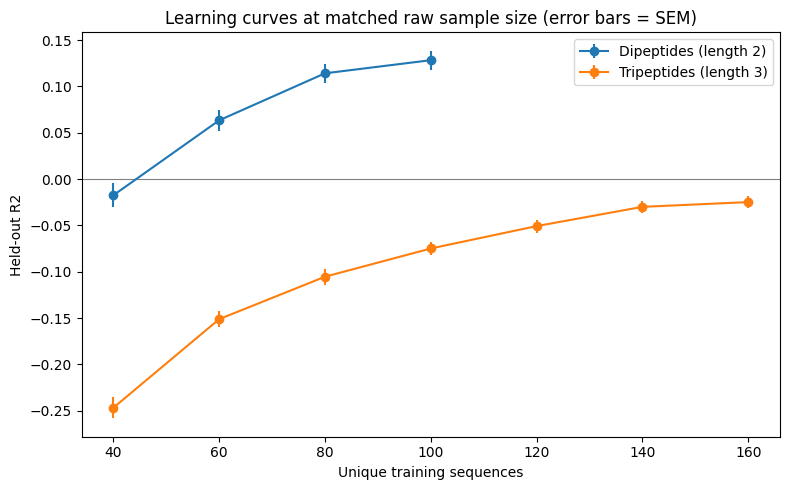


At matched n, dipeptides outperform tripeptides at every point tested.
Tripeptide curve is flat from n=140 to n=160 (~76% of its available pool) -> plateau, not still-rising.


In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(lc2['n_train_unique'], lc2['r2_mean'], yerr=lc2['r2_std']/lc2['n_evals']**0.5,
            marker='o', label='Dipeptides (length 2)')
ax.errorbar(lc3['n_train_unique'], lc3['r2_mean'], yerr=lc3['r2_std']/lc3['n_evals']**0.5,
            marker='o', label='Tripeptides (length 3)')
ax.axhline(0, color='gray', linewidth=0.8)
ax.set_xlabel('Unique training sequences'); ax.set_ylabel('Held-out R2')
ax.set_title('Learning curves at matched raw sample size (error bars = SEM)')
ax.legend(); plt.tight_layout(); plt.show()

print("\nAt matched n, dipeptides outperform tripeptides at every point tested.")
print("Tripeptide curve is flat from n=140 to n=160 (~76% of its available pool) -> plateau, not still-rising.")

## 4. Independent single-source tripeptide table

150 tripeptides with pIC50 values, digitised from a supplied literature table. 83 of these 150
sequences already appear in AHTPDB, and for most of them the values agree almost exactly — strongly
suggesting this table *is* (or is very close to) one of AHTPDB's original contributing studies,
i.e. a single, internally consistent source rather than a noisy multi-study compilation. That makes
it a clean test: if cross-study measurement heterogeneity were the main reason tripeptides are
unpredictable, a single-source dataset should show a visibly better result.

(`starred` marks entries flagged with `*` in the source table — plausibly an original train/test
split from the source publication; we don't have independent confirmation of what it denotes, so
Section 5 tests this assumption rather than taking it at face value.)

In [7]:
# (id, seq, pIC50, starred) — digitised from the supplied table
_records = [
    (1, 'AAP', 4.52, False),
    (2, 'ADA', 3.83, True),
    (3, 'AEL', 4.24, True),
    (4, 'AFL', 4.2, False),
    (5, 'AGP', 3.25, False),
    (6, 'ALP', 3.62, False),
    (7, 'AQL', 4.24, True),
    (8, 'AVP', 3.47, False),
    (9, 'DLP', 5.32, True),
    (10, 'FAL', 4.58, False),
    (11, 'FCF', 4.96, True),
    (12, 'FDK', 3.41, False),
    (13, 'FEP', 4.92, False),
    (14, 'FFF', 4.8, False),
    (15, 'FFG', 3.29, True),
    (16, 'FFL', 4.43, False),
    (17, 'FFP', 4.92, True),
    (18, 'FGF', 4.71, False),
    (19, 'FGG', 3.21, False),
    (20, 'FGK', 3.8, True),
    (21, 'FIV', 3.96, False),
    (22, 'FNF', 5.16, True),
    (23, 'FPF', 4.68, True),
    (24, 'FPK', 3.55, False),
    (25, 'FPP', 4.5, False),
    (26, 'FQP', 4.92, False),
    (27, 'FWN', 4.74, True),
    (28, 'FYN', 4.74, False),
    (29, 'GEG', 3.72, True),
    (30, 'GFF', 4.98, False),
    (31, 'GFG', 3.47, False),
    (32, 'GGF', 4.89, False),
    (33, 'GGG', 3.39, False),
    (34, 'GGP', 4.72, False),
    (35, 'GKV', 5.41, False),
    (36, 'GLG', 3.55, True),
    (37, 'GLY', 5.05, False),
    (38, 'GPL', 5.59, True),
    (39, 'GPM', 4.77, False),
    (40, 'GPP', 4.92, True),
    (41, 'GQP', 5.49, True),
    (42, 'GRP', 4.7, False),
    (43, 'GSH', 4.49, True),
    (44, 'GVV', 4.18, False),
    (45, 'GYG', 3.67, False),
    (46, 'GYY', 4.93, False),
    (47, 'HIR', 3.02, False),
    (48, 'HLL', 4.24, False),
    (49, 'HQG', 3.13, False),
    (50, 'IAE', 4.46, False),
    (51, 'IAP', 5.57, False),
    (52, 'IAQ', 4.46, False),
    (53, 'IFL', 4.35, False),
    (54, 'IKP', 5.68, False),
    (55, 'IKY', 6.68, False),
    (56, 'ILP', 4.49, False),
    (57, 'IMY', 5.74, False),
    (58, 'IPA', 3.85, False),
    (59, 'IPP', 5.3, False),
    (60, 'IRA', 5.01, False),
    (61, 'IRP', 5.74, False),
    (62, 'ITF', 4.31, False),
    (63, 'IVQ', 4.02, False),
    (64, 'IVY', 5.84, False),
    (65, 'IWH', 5.46, False),
    (66, 'IYP', 4.21, False),
    (67, 'KPF', 4.49, False),
    (68, 'LAA', 4.89, False),
    (69, 'LAP', 5.73, False),
    (70, 'LAY', 5.41, True),
    (71, 'LDP', 4.37, False),
    (72, 'LEE', 4.0, False),
    (73, 'LEL', 4.81, False),
    (74, 'LEP', 5.24, False),
    (75, 'LGI', 4.54, False),
    (76, 'LGL', 4.48, False),
    (77, 'LIY', 6.09, False),
    (78, 'LKA', 5.07, False),
    (79, 'LKP', 6.02, False),
    (80, 'LKY', 6.11, True),
    (81, 'LLF', 4.1, False),
    (82, 'LLL', 4.65, True),
    (83, 'LLP', 4.8, False),
    (84, 'LPF', 4.4, False),
    (85, 'LPP', 5.02, False),
    (86, 'LRP', 6.21, False),
    (87, 'LQP', 5.83, False),
    (88, 'LQW', 5.42, True),
    (89, 'LSA', 5.11, False),
    (90, 'LSP', 5.77, False),
    (91, 'LTF', 5.56, False),
    (92, 'LVL', 5.19, False),
    (93, 'LVQ', 4.85, False),
    (94, 'LVR', 4.85, True),
    (95, 'LVY', 5.74, False),
    (96, 'LWA', 4.9, False),
    (97, 'LWY', 5.3, False),
    (98, 'LYP', 5.18, True),
    (99, 'MNP', 4.18, False),
    (100, 'PFP', 4.26, True),
    (101, 'PGI', 3.77, True),
    (102, 'PGG', 2.86, False),
    (103, 'PGL', 4.86, False),
    (104, 'PGP', 4.18, True),
    (105, 'PGR', 3.33, False),
    (106, 'PIP', 4.31, False),
    (107, 'PLW', 4.44, False),
    (108, 'PPG', 2.82, False),
    (109, 'PPP', 4.14, False),
    (110, 'PSY', 4.8, True),
    (111, 'PWP', 3.66, True),
    (112, 'PYP', 3.66, False),
    (113, 'PFH', 3.48, False),
    (114, 'RGP', 4.27, True),
    (115, 'RPG', 2.91, True),
    (116, 'RPP', 4.22, False),
    (117, 'RRR', 4.23, False),
    (118, 'SVY', 5.09, True),
    (119, 'TNP', 3.68, False),
    (120, 'VAA', 4.89, False),
    (121, 'VAF', 4.45, False),
    (122, 'VGP', 4.58, False),
    (123, 'VIY', 5.12, False),
    (124, 'VLP', 4.09, False),
    (125, 'VLY', 4.51, True),
    (126, 'VPP', 5.05, False),
    (127, 'VQV', 5.06, True),
    (128, 'VRP', 5.66, False),
    (129, 'VSP', 5.0, False),
    (130, 'VSW', 4.63, False),
    (131, 'VTR', 3.87, False),
    (132, 'VVF', 4.45, False),
    (133, 'VVV', 4.37, True),
    (134, 'VWY', 5.03, True),
    (135, 'VYP', 3.83, False),
    (136, 'YPF', 4.4, False),
    (137, 'YPR', 4.78, False),
    (138, 'YYY', 4.46, True),
    (139, 'AMY', 5.26, False),
    (140, 'FAP', 5.42, False),
    (141, 'GGY', 5.89, False),
    (142, 'HHL', 5.27, False),
    (143, 'IKW', 6.68, True),
    (144, 'LRY', 6.82, False),
    (145, 'MKY', 5.14, False),
    (146, 'PRY', 5.6, False),
    (147, 'RIY', 4.55, False),
    (148, 'TVY', 4.82, False),
    (149, 'VAP', 5.7, False),
    (150, 'YEY', 5.4, False)
]
new_df = pd.DataFrame(_records, columns=['id', 'seq', 'pIC50', 'starred'])
print("Rows:", len(new_df), "| unique sequences:", new_df['seq'].nunique())
print("Starred (possible test-set) count:", new_df['starred'].sum(), "/", len(new_df))

Rows: 150 | unique sequences: 150
Starred (possible test-set) count: 37 / 150


In [8]:
overlap = set(new_df['seq']) & set(data.loc[data['length']==3, 'seq'])
print(f"Overlap with AHTPDB tripeptides: {len(overlap)} / {len(new_df)}")

agree_check = []
for s in sorted(overlap):
    new_val = new_df.loc[new_df['seq']==s, 'pIC50'].iloc[0]
    aht_vals = data.loc[(data['seq']==s) & (data['length']==3), 'log_ic50'].values
    aht_pic50_equiv = 6 - aht_vals  # log_ic50 is log10(IC50 in uM); pIC50 = -log10(IC50 in M) = 6 - log10(IC50_uM)
    agree_check.append({'seq': s, 'new_pIC50': new_val, 'aht_pIC50_equiv_range': (aht_pic50_equiv.min(), aht_pic50_equiv.max())})
agree_df = pd.DataFrame(agree_check)
print("\nSample of overlap comparison (new table vs AHTPDB-derived pIC50):")
print(agree_df.head(10).to_string(index=False))

Overlap with AHTPDB tripeptides: 83 / 150

Sample of overlap comparison (new table vs AHTPDB-derived pIC50):
seq  new_pIC50                    aht_pIC50_equiv_range
AAP       4.52   (4.522878745280337, 4.522878745280337)
AEL       4.24   (4.243363891754152, 4.243363891754152)
AFL       4.20   (4.185752404268079, 4.195179321278838)
AGP       3.25 (3.2518119729937998, 3.2518119729937998)
ALP       3.62   (3.619788758288394, 3.619788758288394)
AVP       3.47   (3.468521082957745, 3.468521082957745)
DLP       5.32   (5.318758762624412, 5.318758762624412)
FAL       4.58   (4.580044251510242, 4.580044251510242)
FAP       5.42     (5.42021640338319, 5.42021640338319)
FCF       4.96   (4.958607314841775, 4.958607314841775)


In [9]:
desc_new = pd.DataFrame(new_df['seq'].apply(compute_descriptors).tolist(), index=new_df.index)
data_new = pd.concat([new_df, desc_new], axis=1)

from sklearn.model_selection import RepeatedKFold, cross_validate
cv = RepeatedKFold(n_splits=5, n_repeats=20, random_state=RANDOM_STATE)
pipe = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
scores = cross_validate(pipe, data_new[feature_cols], data_new['pIC50'], cv=cv, scoring='r2')
print(f"Single-source tripeptide table (n={len(data_new)}), repeated 5x20 CV: "
      f"R2 = {scores['test_score'].mean():.4f} +/- {scores['test_score'].std():.4f}")

aht_tri_dedup = (data[data['length']==3]
                  .groupby('seq').agg({**{c: 'first' for c in feature_cols}, 'log_ic50': 'median'})
                  .reset_index())
scores_aht = cross_validate(make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
                             aht_tri_dedup[feature_cols], aht_tri_dedup['log_ic50'], cv=cv, scoring='r2')
print(f"For comparison, AHTPDB tripeptides deduped-by-median (n={len(aht_tri_dedup)}), same protocol: "
      f"R2 = {scores_aht['test_score'].mean():.4f} +/- {scores_aht['test_score'].std():.4f}")

Single-source tripeptide table (n=150), repeated 5x20 CV: R2 = 0.0352 +/- 0.1889


For comparison, AHTPDB tripeptides deduped-by-median (n=210), same protocol: R2 = -0.0205 +/- 0.1192


## 5. Split-validity check

If `starred` denotes the source paper's own train/test split, training on non-starred and testing
on starred gives one number. But a single small test set (~37 sequences) can be a lucky or unlucky
draw regardless of whether the split is "special." We check by comparing against 500 random splits
of the same sizes.

In [10]:
train = data_new[~data_new['starred']]
test = data_new[data_new['starred']]
pipe = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
pipe.fit(train[feature_cols], train['pIC50'])
pred = pipe.predict(test[feature_cols])
observed_r2 = r2_score(test['pIC50'], pred)
print(f"Train-on-non-starred / test-on-starred (train n={len(train)}, test n={len(test)}): "
      f"R2 = {observed_r2:.4f}")

n_test = data_new['starred'].sum()
ss = ShuffleSplit(n_splits=500, test_size=n_test/len(data_new), random_state=0)
r2s = []
for tr, te in ss.split(data_new):
    pipe = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
    pipe.fit(data_new[feature_cols].iloc[tr], data_new['pIC50'].iloc[tr])
    pred = pipe.predict(data_new[feature_cols].iloc[te])
    r2s.append(r2_score(data_new['pIC50'].iloc[te], pred))
r2s = np.array(r2s)
print(f"\n500 random splits, same sizes: mean R2 = {r2s.mean():.4f} +/- {r2s.std():.4f}")
print(f"Observed 'starred' split R2={observed_r2:.3f} sits at the "
      f"{(r2s < observed_r2).mean()*100:.1f}th percentile of random splits")
print("-> a favorable draw, not evidence of a genuinely different / more learnable split.")
print("The honest estimate for this dataset is the repeated-CV number from Section 4, not this split.")

Train-on-non-starred / test-on-starred (train n=113, test n=37): R2 = 0.2279



500 random splits, same sizes: mean R2 = 0.0111 +/- 0.2010
Observed 'starred' split R2=0.228 sits at the 93.0th percentile of random splits
-> a favorable draw, not evidence of a genuinely different / more learnable split.
The honest estimate for this dataset is the repeated-CV number from Section 4, not this split.


## 6. Synthesis

- **Learning curves (Section 3):** at every matched raw training-set size, dipeptides substantially
  outpredict tripeptides using the identical representation and model. The tripeptide curve is flat
  (not still rising) using ~76% of its entire available pool — arguing against "just needs more of
  this kind of data" as a sufficient explanation.
- **Independent single-source dataset (Sections 4-5):** removing cross-study measurement
  heterogeneity (by using an apparently single-source, internally consistent tripeptide dataset)
  does **not** rescue tripeptide predictability — R2 remains statistically indistinguishable from
  zero (0.035 +/- 0.189), matching the noisy multi-source AHTPDB result (-0.021 +/- 0.119). The one
  positive-looking number (the starred-split R2=0.228) is a lucky draw at the 93rd percentile of
  random splits, not a real effect.

**Combined conclusion:** across everything tested in this notebook and its companion (four
representations, sample-size scaling, and now two independent datasets with very different noise
profiles), tripeptide unpredictability in this length/sample regime does not trace to representation
choice, available sample size, or cross-study measurement noise. What remains untested is whether a
structurally different approach — one that models the three ACE subsite interactions explicitly
(e.g. explicit pairwise position terms, or a much larger external dataset an order of magnitude
bigger) — can recover signal that none of the methods used so far were able to reach.
